# Brain Tumor MRI Dataset — Rebuild (70/15/15) + Model Benchmark

This notebook rebuilds your **Epic & CSCR Hospital Brain Tumor MRI Dataset** into a clean,
publication-ready release, **then trains 7 models on the new split to sanity-check the
dataset quality before you download anything**:

| Architecture | Paradigm |
|---|---|
| CNN | From scratch |
| ViT | From scratch |
| Hybrid CNN–ViT | From scratch |
| ResNet50 | Frozen pretrained |
| DenseNet121 | Frozen pretrained |
| ResNet50 | Fine-tuned |
| DenseNet121 | Fine-tuned |

**Pipeline:**
1. Upload & extract your original ZIP(s).
2. Discover images, merge old Train+Test into one pool.
3. Remove exact duplicates (MD5) and near-duplicates (perceptual hash) — the main source
   of hidden train/test leakage.
4. Stratified 70/15/15 split (every split mirrors the overall class balance).
5. Hard assertion that zero images overlap across splits.
6. Rebuild the dataset folder with anonymized filenames.
7. **Train all 7 models on the new split and report Test Accuracy / Test F1** — this is
   your confirmation the dataset is clean and learnable before you package it.
8. Only then: generate the dataset README/card, zip, and download.

> ⚠️ **GPU required.** Go to `Runtime > Change runtime type > T4 GPU` before running, or
> the benchmarking section (Step 11) will be extremely slow.

> ⚠️ **Leakage caveat**: this pipeline catches file-level exact/near duplicates. It cannot
> know which images share the same **patient** unless that's encoded in the filenames —
> see the optional patient-level split cell (Step 3B) if applicable to your data.


## Step 0 — Install & import dependencies

In [1]:
!pip install imagehash tqdm timm -q

import os, io, shutil, hashlib, zipfile, json, random, copy, time
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import imagehash

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✅ Environment ready")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 12.6 MB/s eta 0:00:00
✅ Environment ready


## Step 1 — Upload your dataset ZIP file(s)

Upload the same ZIP file(s) you used originally. You can upload one ZIP or several
(e.g. old Train / Test zips) — everything gets merged before re-splitting, so the
original Train/Test boundary doesn't matter anymore.


In [2]:
from google.colab import files

uploaded = files.upload()

extracted_dirs = []
for filename in uploaded.keys():
    foldername = filename.rsplit('.', 1)[0].replace(' ', '_').lower() + "_raw"
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall(foldername)
    extracted_dirs.append(foldername)
    print(f"✅ Extracted {filename} -> {foldername}")

print("\nExtracted root folders:", extracted_dirs)


Saving Epic and CSCR hospital Dataset.zip to Epic and CSCR hospital Dataset.zip
✅ Extracted Epic and CSCR hospital Dataset.zip -> epic_and_cscr_hospital_dataset_raw

Extracted root folders: ['epic_and_cscr_hospital_dataset_raw']


## Step 2 — Configure class names & discover every image

Edit `CLASS_ALIASES` only if your folder names differ from the variants already listed.


In [3]:
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

CLASS_ALIASES = {
    'glioma':      ['glioma', 'glioma_tumor', 'gliomas'],
    'meningioma':  ['meningioma', 'meningioma_tumor', 'meningiomas'],
    'pituitary':   ['pituitary', 'pituitary_tumor', 'pituitary_gland'],
    'no_tumor':    ['no_tumor', 'notumor', 'no tumor', 'normal', 'healthy'],
}

def normalize(name):
    return name.strip().lower().replace('-', '_').replace(' ', '_')

_ALIAS_LOOKUP = {}
for canonical, variants in CLASS_ALIASES.items():
    for v in variants:
        _ALIAS_LOOKUP[normalize(v)] = canonical

def match_class(folder_name):
    return _ALIAS_LOOKUP.get(normalize(folder_name))

records = []
for root_dir in extracted_dirs:
    for cur_root, dirs, filenames in os.walk(root_dir):
        cls = match_class(os.path.basename(cur_root))
        if cls is None:
            continue
        for fname in filenames:
            if fname.lower().endswith(IMG_EXTS):
                records.append({'filepath': os.path.join(cur_root, fname), 'class': cls})

df = pd.DataFrame(records)
assert len(df) > 0, "No images were found — check CLASS_ALIASES / your folder names."

print(f"📦 Discovered {len(df)} images across {df['class'].nunique()} classes\n")
print(df['class'].value_counts())


📦 Discovered 11148 images across 4 classes

class
glioma        3621
meningioma    2619
pituitary     2574
no_tumor      2334
Name: count, dtype: int64


## Step 3 — Remove exact duplicates (MD5)

Byte-identical files — the most common and most dangerous form of leakage.


In [4]:
def md5_of_file(path, chunk_size=1 << 16):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for block in iter(lambda: f.read(chunk_size), b''):
            h.update(block)
    return h.hexdigest()

tqdm.pandas(desc="Hashing files (MD5)")
df['md5'] = df['filepath'].progress_apply(md5_of_file)

before = len(df)

conflict = df.groupby('md5')['class'].nunique()
conflicting_hashes = conflict[conflict > 1].index.tolist()
if conflicting_hashes:
    print(f"⚠️ {len(conflicting_hashes)} exact-duplicate image(s) found under DIFFERENT class labels.")
    print("   Keeping only the first labeled occurrence for each — please review manually:")
    display(df[df['md5'].isin(conflicting_hashes)].sort_values('md5')[['filepath', 'class', 'md5']])

df = df.drop_duplicates(subset='md5', keep='first').reset_index(drop=True)
after = len(df)

print(f"\n🧹 Removed {before - after} exact-duplicate files ({before} -> {after})")
print(df['class'].value_counts())


Hashing files (MD5):   0%|          | 0/11148 [00:00<?, ?it/s]


🧹 Removed 833 exact-duplicate files (11148 -> 10315)
class
glioma        3545
pituitary     2410
meningioma    2307
no_tumor      2053
Name: count, dtype: int64


## Step 3A — Remove near-duplicates (perceptual hash)

Catches visually near-identical images that aren't byte-identical (re-exported,
re-compressed, resized, minimally cropped). Computed per class.


In [5]:
PHASH_THRESHOLD = 5   # 0 = perceptually identical only. 5 is a safe, conservative default.

def compute_phash(path):
    try:
        return imagehash.phash(Image.open(path).convert('L'))
    except Exception:
        return None

tqdm.pandas(desc="Computing perceptual hashes")
df['phash'] = df['filepath'].progress_apply(compute_phash)
df = df[df['phash'].notna()].reset_index(drop=True)

to_drop = set()
for cls, group in df.groupby('class'):
    idx = group.index.to_numpy()
    bits = np.array([g.hash.flatten() for g in group['phash']], dtype=np.int8)
    n_bits = bits.shape[1]
    signed = bits * 2 - 1
    dot = signed @ signed.T
    hamming = (n_bits - dot) // 2

    n = len(idx)
    for i in range(n):
        if idx[i] in to_drop:
            continue
        dup_js = np.where(hamming[i, i + 1:] <= PHASH_THRESHOLD)[0] + (i + 1)
        for j in dup_js:
            to_drop.add(idx[j])

before = len(df)
df = df.drop(index=to_drop).reset_index(drop=True)
after = len(df)

print(f"🧹 Removed {before - after} near-duplicate images (threshold <= {PHASH_THRESHOLD} bits)")
print(df['class'].value_counts())


Computing perceptual hashes:   0%|          | 0/10315 [00:00<?, ?it/s]

🧹 Removed 4374 near-duplicate images (threshold <= 5 bits)
class
glioma        2191
pituitary     1485
meningioma    1478
no_tumor       787
Name: count, dtype: int64


## Step 3B (optional) — Patient-level grouping

**Skip if your filenames don't contain a patient/study ID.** If they do, edit
`extract_patient_id` and set `USE_PATIENT_LEVEL_SPLIT = True` so every image from the
same patient stays in a single split.


In [6]:
USE_PATIENT_LEVEL_SPLIT = False  # set True after configuring extract_patient_id below

def extract_patient_id(filepath):
    """Return a patient/study ID parsed from the filename, or None if unknown.
    Edit to match your naming convention, e.g. 'patient0231_slice04.jpg' -> 'patient0231'.
    """
    stem = Path(filepath).stem
    return stem.split('_')[0] if '_' in stem else None

if USE_PATIENT_LEVEL_SPLIT:
    df['patient_id'] = df['filepath'].apply(extract_patient_id)
    missing = df['patient_id'].isna().sum()
    print(f"Parsed patient IDs for {len(df) - missing}/{len(df)} images ({missing} unmatched).")
else:
    print("Patient-level split disabled — using image-level stratified split (Step 4).")


Patient-level split disabled — using image-level stratified split (Step 4).


## Step 4 — Stratified 70 / 15 / 15 split

Each class is shuffled (fixed seed) and sliced independently, so every split mirrors
the overall class distribution.


In [7]:
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9

def stratified_split(frame, group_col, train_ratio, val_ratio, seed=SEED):
    train_parts, val_parts, test_parts = [], [], []
    for cls, group in frame.groupby('class'):
        units = group[group_col].unique()
        rng = np.random.RandomState(seed)
        rng.shuffle(units)

        n = len(units)
        n_train = int(round(n * train_ratio))
        n_val = int(round(n * val_ratio))
        n_train = min(n_train, n)
        n_val = min(n_val, n - n_train)

        train_units = set(units[:n_train])
        val_units = set(units[n_train:n_train + n_val])
        test_units = set(units[n_train + n_val:])

        train_parts.append(group[group[group_col].isin(train_units)])
        val_parts.append(group[group[group_col].isin(val_units)])
        test_parts.append(group[group[group_col].isin(test_units)])

    return (pd.concat(train_parts).reset_index(drop=True),
            pd.concat(val_parts).reset_index(drop=True),
            pd.concat(test_parts).reset_index(drop=True))

if USE_PATIENT_LEVEL_SPLIT and 'patient_id' in df.columns and df['patient_id'].notna().all():
    group_col = 'patient_id'
else:
    df['_uid'] = df['md5']
    group_col = '_uid'

train_df, val_df, test_df = stratified_split(df, group_col, TRAIN_RATIO, VAL_RATIO)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}  |  Total: {len(df)}")
summary = pd.DataFrame({
    'train': train_df['class'].value_counts(),
    'val':   val_df['class'].value_counts(),
    'test':  test_df['class'].value_counts(),
}).fillna(0).astype(int)
summary['total'] = summary.sum(axis=1)
summary.loc['TOTAL'] = summary.sum()
print(summary)


Train: 4160  |  Val: 892  |  Test: 889  |  Total: 5941
            train  val  test  total
class                              
glioma       1534  329   328   2191
pituitary    1040  223   222   1485
meningioma   1035  222   221   1478
no_tumor      551  118   118    787
TOTAL        4160  892   889   5941


## Step 5 — Verify: zero leakage across splits

The notebook stops here with an error if any image (by content hash) appears in more
than one split.


In [8]:
train_hashes = set(train_df['md5'])
val_hashes = set(val_df['md5'])
test_hashes = set(test_df['md5'])

assert not (train_hashes & val_hashes), "Leakage detected between train/val"
assert not (train_hashes & test_hashes), "Leakage detected between train/test"
assert not (val_hashes & test_hashes), "Leakage detected between val/test"
assert len(train_df) + len(val_df) + len(test_df) == len(df), "Row counts don't add up!"

print("✅ No data leakage: train/val/test share zero images (verified by content hash).")
print(f"✅ Row counts reconcile: {len(train_df)} + {len(val_df)} + {len(test_df)} = {len(df)}")


✅ No data leakage: train/val/test share zero images (verified by content hash).
✅ Row counts reconcile: 4160 + 892 + 889 = 5941


## Step 6 — Build the final dataset folder (anonymized filenames)


In [9]:
OUTPUT_ROOT = 'Brain_Tumor_MRI_Dataset_Final'
CLASSES = sorted(df['class'].unique())
SPLITS = {'train': train_df, 'val': val_df, 'test': test_df}

if os.path.exists(OUTPUT_ROOT):
    shutil.rmtree(OUTPUT_ROOT)

for split_name, split_df in SPLITS.items():
    for cls in CLASSES:
        os.makedirs(os.path.join(OUTPUT_ROOT, split_name, cls), exist_ok=True)

    counters = defaultdict(int)
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Copying {split_name}"):
        counters[row['class']] += 1
        ext = os.path.splitext(row['filepath'])[1].lower()
        if ext not in IMG_EXTS:
            ext = '.jpg'
        new_name = f"{row['class']}_{split_name}_{counters[row['class']]:05d}{ext}"
        dest = os.path.join(OUTPUT_ROOT, split_name, row['class'], new_name)
        shutil.copy2(row['filepath'], dest)

print(f"✅ Final dataset written to ./{OUTPUT_ROOT}")


Copying train:   0%|          | 0/4160 [00:00<?, ?it/s]

Copying val:   0%|          | 0/892 [00:00<?, ?it/s]

Copying test:   0%|          | 0/889 [00:00<?, ?it/s]

✅ Final dataset written to ./Brain_Tumor_MRI_Dataset_Final


## Step 7 — Sanity check the copied files on disk

In [10]:
final_counts = {}
for split_name in SPLITS:
    final_counts[split_name] = {}
    for cls in CLASSES:
        p = os.path.join(OUTPUT_ROOT, split_name, cls)
        n = len([f for f in os.listdir(p) if f.lower().endswith(IMG_EXTS)])
        final_counts[split_name][cls] = n

final_df = pd.DataFrame(final_counts)
final_df['total'] = final_df.sum(axis=1)
final_df.loc['TOTAL'] = final_df.sum()
print(final_df)

expected_total = len(df)
actual_total = final_df.loc['TOTAL', 'total']
assert expected_total == actual_total, f"Mismatch! expected {expected_total}, got {actual_total}"
print(f"\n✅ On-disk file count matches expected total: {actual_total}")


            train  val  test  total
glioma       1534  329   328   2191
meningioma   1035  222   221   1478
no_tumor      551  118   118    787
pituitary    1040  223   222   1485
TOTAL        4160  892   889   5941

✅ On-disk file count matches expected total: 5941


## Step 8 — Class distribution report (publication-quality figure)

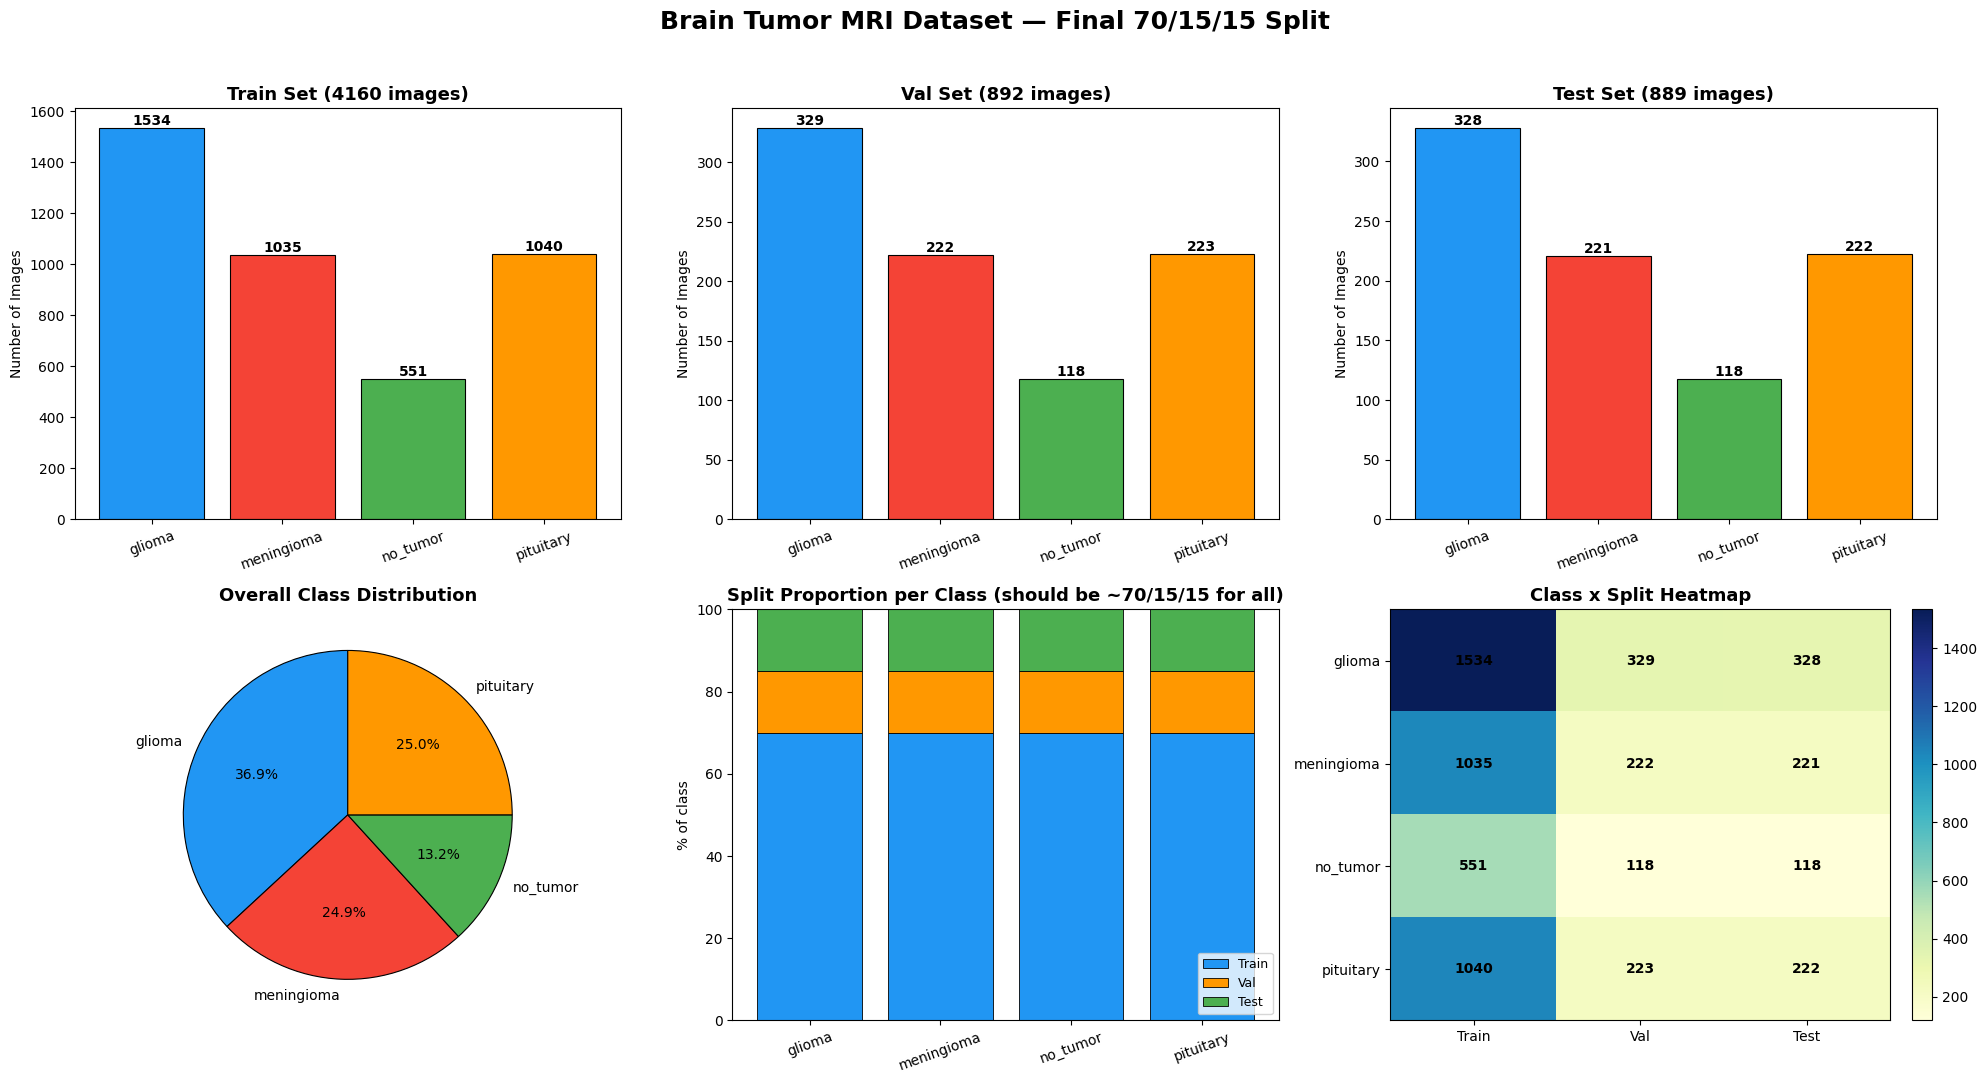

✅ Saved figure: class_distribution_final.png


In [11]:
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']
class_colors = {cls: colors[i % len(colors)] for i, cls in enumerate(CLASSES)}

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Brain Tumor MRI Dataset — Final 70/15/15 Split', fontsize=18, fontweight='bold')

for ax, split_name in zip(axes[0], ['train', 'val', 'test']):
    vals = [final_counts[split_name][c] for c in CLASSES]
    bars = ax.bar(CLASSES, vals, color=[class_colors[c] for c in CLASSES], edgecolor='black', linewidth=0.8)
    ax.set_title(f'{split_name.capitalize()} Set ({sum(vals)} images)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=20)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

overall = final_df.loc[CLASSES, 'total']
axes[1][0].pie(overall, labels=CLASSES, autopct='%1.1f%%', colors=[class_colors[c] for c in CLASSES],
               startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
axes[1][0].set_title('Overall Class Distribution', fontsize=13, fontweight='bold')

props = final_df.loc[CLASSES, ['train', 'val', 'test']].div(final_df.loc[CLASSES, 'total'], axis=0) * 100
bottom = np.zeros(len(CLASSES))
for split_name, c in zip(['train', 'val', 'test'], ['#2196F3', '#FF9800', '#4CAF50']):
    axes[1][1].bar(CLASSES, props[split_name], bottom=bottom, label=split_name.capitalize(), color=c, edgecolor='black', linewidth=0.6)
    bottom += props[split_name].values
axes[1][1].set_ylim(0, 100)
axes[1][1].set_ylabel('% of class')
axes[1][1].set_title('Split Proportion per Class (should be ~70/15/15 for all)', fontsize=13, fontweight='bold')
axes[1][1].legend(loc='lower right', fontsize=9)
axes[1][1].tick_params(axis='x', rotation=20)

heat = final_df.loc[CLASSES, ['train', 'val', 'test']].values
im = axes[1][2].imshow(heat, cmap='YlGnBu', aspect='auto')
axes[1][2].set_xticks(range(3)); axes[1][2].set_xticklabels(['Train', 'Val', 'Test'])
axes[1][2].set_yticks(range(len(CLASSES))); axes[1][2].set_yticklabels(CLASSES)
for i in range(len(CLASSES)):
    for j in range(3):
        axes[1][2].text(j, i, str(heat[i, j]), ha='center', va='center', fontsize=10, fontweight='bold')
axes[1][2].set_title('Class x Split Heatmap', fontsize=13, fontweight='bold')
fig.colorbar(im, ax=axes[1][2], fraction=0.046, pad=0.04)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('class_distribution_final.png', dpi=200, bbox_inches='tight')
plt.show()

print("✅ Saved figure: class_distribution_final.png")


# Model Benchmark — confirm the dataset before you download

The next steps train **7 models** on the new 70/15/15 split and report **Test Accuracy**
and **Test F1** for each, so you can confirm the dataset is clean and learnable before
packaging it. Expect the general pattern: fine-tuned pretrained models > frozen
pretrained > from-scratch, and CNNs typically outperform from-scratch ViTs on datasets
this size.

**Runtime**: with a T4 GPU and the default epoch settings below, all 7 models together
take roughly 45–90 minutes. Reduce the `epochs` values in `MODEL_CONFIGS` (Step 10) for a
faster, rougher check.


## Step 9 — Build DataLoaders from the final split

In [12]:
IMG_SIZE = 224
BATCH_SIZE = 32

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_ds = datasets.ImageFolder(os.path.join(OUTPUT_ROOT, 'train'), transform=train_transform)
val_ds   = datasets.ImageFolder(os.path.join(OUTPUT_ROOT, 'val'),   transform=eval_transform)
test_ds  = datasets.ImageFolder(os.path.join(OUTPUT_ROOT, 'test'),  transform=eval_transform)

assert train_ds.classes == val_ds.classes == test_ds.classes
num_classes = len(train_ds.classes)
print("Classes:", train_ds.classes)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
if device.type == 'cpu':
    print("⚠️ No GPU detected — Runtime > Change runtime type > GPU is strongly recommended.")


Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Device: cuda


## Step 10 — Define the 7 architectures

- **CNN (from scratch)** — small custom conv net.
- **ViT (from scratch)** — `vit_tiny_patch16_224` via `timm`, random init.
- **Hybrid CNN–ViT (from scratch)** — `vit_small_r26_s32_224` (ResNet stem + ViT), via
  `timm`, random init.
- **ResNet50 / DenseNet121 (frozen pretrained)** — ImageNet weights, backbone frozen,
  only the new classifier head is trained.
- **ResNet50 / DenseNet121 (fine-tuned)** — ImageNet weights, all layers trainable.


In [15]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        x = self.dropout(x)
        return self.classifier(x)


def build_model(arch_key, num_classes):
    if arch_key == 'cnn_scratch':
        return SimpleCNN(num_classes)
    elif arch_key == 'vit_scratch':
        return timm.create_model('vit_tiny_patch16_224', pretrained=False, num_classes=num_classes)
    elif arch_key == 'hybrid_scratch':
        return timm.create_model('vit_small_r26_s32_224', pretrained=False, num_classes=num_classes)
    elif arch_key == 'resnet50_frozen':
        m = timm.create_model('resnet50', pretrained=True, num_classes=num_classes)
        for p in m.parameters():
            p.requires_grad = False
        for p in m.get_classifier().parameters():
            p.requires_grad = True
        return m
    elif arch_key == 'densenet121_frozen':
        m = timm.create_model('densenet121', pretrained=True, num_classes=num_classes)
        for p in m.parameters():
            p.requires_grad = False
        for p in m.get_classifier().parameters():
            p.requires_grad = True
        return m
    elif arch_key == 'resnet50_finetuned':
        return timm.create_model('resnet50', pretrained=True, num_classes=num_classes)
    elif arch_key == 'densenet121_finetuned':
        return timm.create_model('densenet121', pretrained=True, num_classes=num_classes)
    else:
        raise ValueError(f"Unknown arch_key: {arch_key}")


MODEL_CONFIGS = [
    dict(key='cnn_scratch',           display='CNN',            paradigm='From scratch',     epochs=30, lr=1e-3),
    dict(key='vit_scratch',           display='ViT',             paradigm='From scratch',     epochs=30, lr=3e-4),
    dict(key='hybrid_scratch',        display='Hybrid CNN–ViT',  paradigm='From scratch',     epochs=30, lr=3e-4),
    dict(key='resnet50_frozen',       display='ResNet50',        paradigm='Frozen pretrained', epochs=30,  lr=1e-3),
    dict(key='densenet121_frozen',    display='DenseNet121',     paradigm='Frozen pretrained', epochs=30,  lr=1e-3),
    dict(key='resnet50_finetuned',    display='ResNet50',        paradigm='Fine-tuned',       epochs=30,  lr=1e-4),
    dict(key='densenet121_finetuned', display='DenseNet121',     paradigm='Fine-tuned',       epochs=30,  lr=1e-4),
]

print(f"Configured {len(MODEL_CONFIGS)} models to benchmark.")


Configured 7 models to benchmark.


## Step 11 — Train & evaluate each model

In [16]:
def train_and_evaluate(model, name, train_loader, val_loader, test_loader, epochs, lr, device, weight_decay=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1))

    best_val_acc = -1.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)
        val_loss, val_acc = val_loss / val_total, val_correct / val_total
        scheduler.step()

        print(f"[{name}] epoch {epoch+1:>2}/{epochs} | train_loss {train_loss:.4f} train_acc {train_acc:.4f} | val_loss {val_loss:.4f} val_acc {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    test_acc = accuracy_score(all_labels, all_preds)
    test_f1 = f1_score(all_labels, all_preds, average='weighted')
    return test_acc, test_f1


results = []
for cfg in MODEL_CONFIGS:
    print("=" * 80)
    print(f"Training {cfg['display']} ({cfg['paradigm']})  —  {cfg['epochs']} epochs, lr={cfg['lr']}")
    print("=" * 80)
    t0 = time.time()

    model = build_model(cfg['key'], num_classes)
    test_acc, test_f1 = train_and_evaluate(
        model, cfg['display'], train_loader, val_loader, test_loader,
        epochs=cfg['epochs'], lr=cfg['lr'], device=device,
    )
    elapsed = time.time() - t0

    print(f"✅ {cfg['display']} ({cfg['paradigm']}) — Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f} | {elapsed/60:.1f} min\n")

    results.append({
        'Architecture': cfg['display'],
        'Paradigm': cfg['paradigm'],
        'Test Acc.': round(test_acc, 4),
        'Test F1': round(test_f1, 4),
    })

    del model
    if device.type == 'cuda':
        torch.cuda.empty_cache()

results_df = pd.DataFrame(results)
print("\n\nBenchmark complete.")


Training CNN (From scratch)  —  30 epochs, lr=0.001
[CNN] epoch  1/30 | train_loss 1.0422 train_acc 0.5635 | val_loss 1.0533 val_acc 0.5415
[CNN] epoch  2/30 | train_loss 0.9307 train_acc 0.6082 | val_loss 0.9133 val_acc 0.6525
[CNN] epoch  3/30 | train_loss 0.8737 train_acc 0.6591 | val_loss 0.8886 val_acc 0.6760
[CNN] epoch  4/30 | train_loss 0.8189 train_acc 0.6856 | val_loss 0.8001 val_acc 0.6581
[CNN] epoch  5/30 | train_loss 0.7808 train_acc 0.7024 | val_loss 0.7576 val_acc 0.7220
[CNN] epoch  6/30 | train_loss 0.7475 train_acc 0.7094 | val_loss 0.9497 val_acc 0.6087
[CNN] epoch  7/30 | train_loss 0.7040 train_acc 0.7406 | val_loss 1.1967 val_acc 0.5258
[CNN] epoch  8/30 | train_loss 0.6855 train_acc 0.7358 | val_loss 1.0287 val_acc 0.6110
[CNN] epoch  9/30 | train_loss 0.6457 train_acc 0.7625 | val_loss 1.0608 val_acc 0.5908
[CNN] epoch 10/30 | train_loss 0.6343 train_acc 0.7541 | val_loss 0.6596 val_acc 0.7152
[CNN] epoch 11/30 | train_loss 0.6070 train_acc 0.7748 | val_loss 0.

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

[ResNet50] epoch  1/30 | train_loss 1.1058 train_acc 0.5474 | val_loss 0.9765 val_acc 0.7119
[ResNet50] epoch  2/30 | train_loss 0.8702 train_acc 0.6909 | val_loss 0.8290 val_acc 0.7500
[ResNet50] epoch  3/30 | train_loss 0.7689 train_acc 0.7279 | val_loss 0.7488 val_acc 0.7635
[ResNet50] epoch  4/30 | train_loss 0.7209 train_acc 0.7416 | val_loss 0.7207 val_acc 0.7668
[ResNet50] epoch  5/30 | train_loss 0.6787 train_acc 0.7565 | val_loss 0.6751 val_acc 0.7791
[ResNet50] epoch  6/30 | train_loss 0.6573 train_acc 0.7695 | val_loss 0.6526 val_acc 0.8004
[ResNet50] epoch  7/30 | train_loss 0.6346 train_acc 0.7755 | val_loss 0.6306 val_acc 0.7915
[ResNet50] epoch  8/30 | train_loss 0.6016 train_acc 0.7822 | val_loss 0.6144 val_acc 0.7937
[ResNet50] epoch  9/30 | train_loss 0.6008 train_acc 0.7829 | val_loss 0.6213 val_acc 0.7836
[ResNet50] epoch 10/30 | train_loss 0.5821 train_acc 0.7942 | val_loss 0.5991 val_acc 0.7960
[ResNet50] epoch 11/30 | train_loss 0.5643 train_acc 0.8000 | val_loss

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

[DenseNet121] epoch  1/30 | train_loss 0.8162 train_acc 0.6827 | val_loss 0.6236 val_acc 0.8004
[DenseNet121] epoch  2/30 | train_loss 0.5847 train_acc 0.7863 | val_loss 0.5546 val_acc 0.7960
[DenseNet121] epoch  3/30 | train_loss 0.5179 train_acc 0.8137 | val_loss 0.4982 val_acc 0.8341
[DenseNet121] epoch  4/30 | train_loss 0.4840 train_acc 0.8226 | val_loss 0.4715 val_acc 0.8307
[DenseNet121] epoch  5/30 | train_loss 0.4645 train_acc 0.8325 | val_loss 0.4836 val_acc 0.8251
[DenseNet121] epoch  6/30 | train_loss 0.4423 train_acc 0.8377 | val_loss 0.4415 val_acc 0.8543
[DenseNet121] epoch  7/30 | train_loss 0.4144 train_acc 0.8471 | val_loss 0.4410 val_acc 0.8509
[DenseNet121] epoch  8/30 | train_loss 0.4128 train_acc 0.8474 | val_loss 0.4151 val_acc 0.8587
[DenseNet121] epoch  9/30 | train_loss 0.4067 train_acc 0.8560 | val_loss 0.4087 val_acc 0.8587
[DenseNet121] epoch 10/30 | train_loss 0.3889 train_acc 0.8524 | val_loss 0.4216 val_acc 0.8487
[DenseNet121] epoch 11/30 | train_loss 0

## Step 12 — Results table & comparison chart

,Architecture,Paradigm,Test Acc.,Test F1
0,CNN,From scratch,0.8470,0.8457
1,ViT,From scratch,0.8256,0.8240
2,Hybrid CNN–ViT,From scratch,0.8189,0.8201
3,ResNet50,Frozen pretrained,0.8031,0.8022
4,DenseNet121,Frozen pretrained,0.8706,0.8703
5,ResNet50,Fine-tuned,0.9708,0.9708
6,DenseNet121,Fine-tuned,0.9831,0.9831


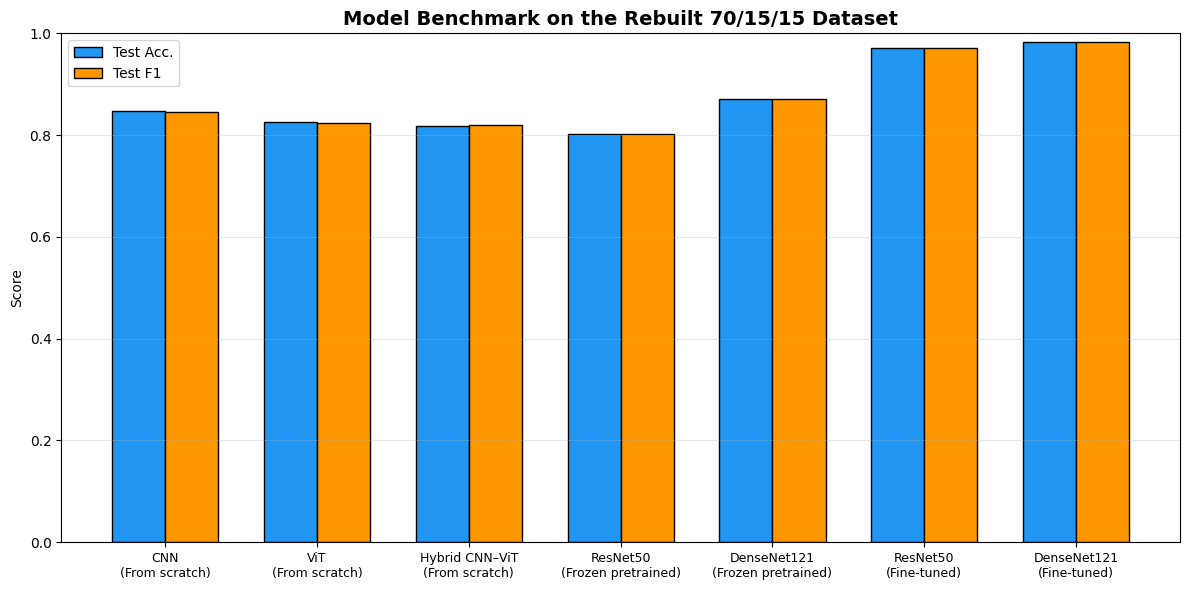

  Architecture          Paradigm  Test Acc.  Test F1
           CNN      From scratch     0.8470   0.8457
           ViT      From scratch     0.8256   0.8240
Hybrid CNN–ViT      From scratch     0.8189   0.8201
      ResNet50 Frozen pretrained     0.8031   0.8022
   DenseNet121 Frozen pretrained     0.8706   0.8703
      ResNet50        Fine-tuned     0.9708   0.9708
   DenseNet121        Fine-tuned     0.9831   0.9831


In [17]:
def highlight_best(s):
    is_max = s == s.max()
    return ['font-weight: bold' if v else '' for v in is_max]

styled = results_df.style.apply(highlight_best, subset=['Test Acc.', 'Test F1']).format({'Test Acc.': '{:.4f}', 'Test F1': '{:.4f}'})
display(styled)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.35
labels = [f"{r['Architecture']}\n({r['Paradigm']})" for _, r in results_df.iterrows()]

ax.bar(x - width/2, results_df['Test Acc.'], width, label='Test Acc.', color='#2196F3', edgecolor='black')
ax.bar(x + width/2, results_df['Test F1'], width, label='Test F1', color='#FF9800', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Benchmark on the Rebuilt 70/15/15 Dataset', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_benchmark.png', dpi=200, bbox_inches='tight')
plt.show()

print(results_df.to_string(index=False))


**Review the table above.** If the pattern looks healthy (fine-tuned models scoring
highest, results reasonably in line with what you'd expect for this task) that's a good
sign the dataset is clean and free of the kind of leakage that produces artificially
inflated numbers. If something looks off — e.g. suspiciously perfect scores even for the
from-scratch models — that can itself be a sign of remaining leakage worth investigating
(try lowering `PHASH_THRESHOLD` in Step 3A, or enabling the patient-level split in Step 3B).

Once you're happy with the results, continue to the packaging steps below.


## Step 13 — Generate a dataset card (`README.md`)

Fill in the bracketed placeholders (license, citation, contact) before publishing.
The benchmark results from Step 12 are embedded automatically.


In [18]:
readme_text = f'''# Brain Tumor MRI Dataset (Glioma, Meningioma, Pituitary, No Tumor)

## Overview
- **Task**: Multi-class brain tumor classification from MRI images
- **Classes**: {', '.join(c.capitalize() for c in CLASSES)}
- **Total images**: {len(df)} (after exact- and near-duplicate removal)
- **Split**: 70% Train / 15% Validation / 15% Test, stratified per class
- **Source**: Epic & CSCR Hospital [add full attribution / consent statement here]
- **License**: [FILL IN — e.g. CC BY-NC 4.0]
- **Citation**: [FILL IN — how you'd like this dataset cited]

## Preprocessing & integrity
1. Combined the original Train/Test images into a single pool.
2. Removed exact byte-identical duplicate files (MD5 hash).
3. Removed near-duplicate images via perceptual hashing (`imagehash.phash`,
   Hamming distance <= {PHASH_THRESHOLD}).
4. Re-split into Train/Val/Test with a per-class stratified split (fixed seed = {SEED})
   so every split preserves the overall class distribution.
5. Verified **zero image-content overlap** between Train/Val/Test.
6. Renamed all files to anonymized, sequential names (`<class>_<split>_<index>.<ext>`).

## Class distribution

{final_df.to_markdown()}

## Baseline model benchmark
Reported on the Test split described above.

{results_df.to_markdown(index=False)}

## Directory structure
```
{OUTPUT_ROOT}/
    train/
        glioma/
        meningioma/
        pituitary/
        no_tumor/
    val/
        ...
    test/
        ...
```

## Known limitations
- Duplicate/near-duplicate removal is image-level. If multiple images come from the same
  patient/study and are not visually near-identical, patient-level leakage may still be
  possible unless the patient-level split option was used when building this release.
'''

with open(os.path.join(OUTPUT_ROOT, 'README.md'), 'w') as f:
    f.write(readme_text)

final_df.to_csv(os.path.join(OUTPUT_ROOT, 'class_distribution.csv'))
results_df.to_csv(os.path.join(OUTPUT_ROOT, 'model_benchmark.csv'), index=False)
shutil.copy2('class_distribution_final.png', os.path.join(OUTPUT_ROOT, 'class_distribution_final.png'))
shutil.copy2('model_benchmark.png', os.path.join(OUTPUT_ROOT, 'model_benchmark.png'))

print("✅ README.md, class_distribution.csv and model_benchmark.csv written into the dataset folder")


✅ README.md, class_distribution.csv and model_benchmark.csv written into the dataset folder


## Step 14 — Zip and download the final dataset

Produces `Brain_Tumor_MRI_Dataset_Final.zip`, ready to upload to Kaggle / Hugging Face /
Zenodo / etc.


In [19]:
zip_path = shutil.make_archive(OUTPUT_ROOT, 'zip', OUTPUT_ROOT)
print(f"✅ Created {zip_path}  ({os.path.getsize(zip_path) / (1024**2):.1f} MB)")

files.download(zip_path)


✅ Created /content/Brain_Tumor_MRI_Dataset_Final.zip  (107.1 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### (Optional) Save to Google Drive instead of / in addition to downloading


In [20]:
# from google.colab import drive
# drive.mount('/content/drive')
# shutil.copy2(zip_path, '/content/drive/MyDrive/' + os.path.basename(zip_path))
# print("✅ Copied to Google Drive")
